In [205]:
import pandas as pd

churn = pd.read_csv('Churn_Modelling.csv').drop(columns=['RowNumber'])

In [206]:
churn = churn.dropna()

<Axes: xlabel='Gender', ylabel='Count'>

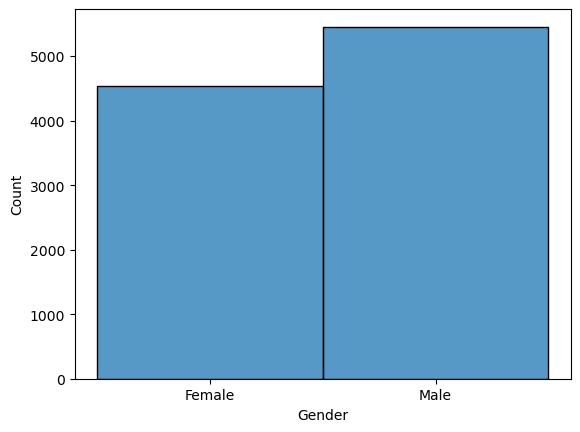

In [207]:
import seaborn as sb

sb.histplot(
    churn,
    x="Gender"
)

In [208]:
male_count = churn[churn.Gender == "Male"].shape[0]
female_count = churn[churn.Gender == "Female"].shape[0]
print(f'Male :{male_count}')
print(f'Female: {female_count}')

Male :5455
Female: 4543


In [ ]:
# unequal_gender = male_count - female_count
# drop_unequal_index = churn[churn["Gender"] == "Male"].iloc[:unequal_gender].index
# churn = churn.drop(drop_unequal_index, axis=0)

<Axes: ylabel='count'>

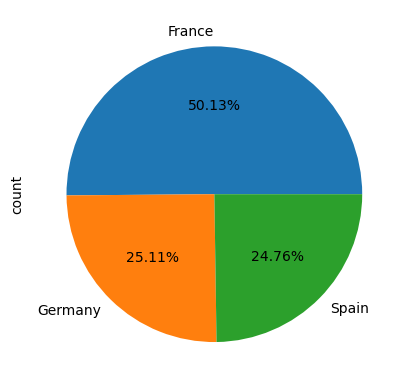

In [210]:
import matplotlib.pyplot as plt

churn['Geography'].value_counts().plot.pie(autopct="%.2f%%")

In [211]:
churn.loc[:, 'Age':].describe()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000
mean,38.920287,5.013003,76481.490819,1.530206,0.705541,0.514803,100099.786455,0.203841
std,10.487986,2.892152,62393.187035,0.581669,0.455822,0.499806,57510.939962,0.402872
min,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,37.000000,5.000000,97173.290000,1.000000,1.000000,1.000000,100218.210000,0.000000
75%,44.000000,7.000000,127641.417500,2.000000,1.000000,1.000000,149395.882500,0.000000
max,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [ ]:
# values_drop = churn[churn['Balance'] == 0].index
# churn_no_zero = churn.drop(index=values_drop)

In [212]:
X = churn.loc[:, 'CreditScore':'EstimatedSalary']
y = churn['Exited']

RandomForest: 0.8618 (+/- 0.0128)


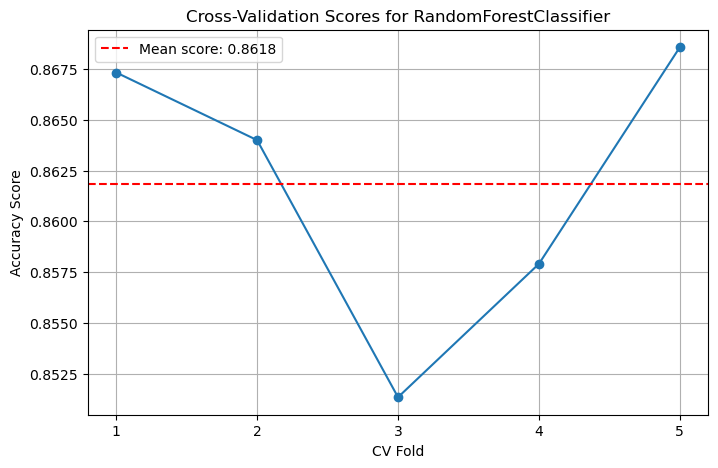

LogisticRegression: 0.8105 (+/- 0.0081)


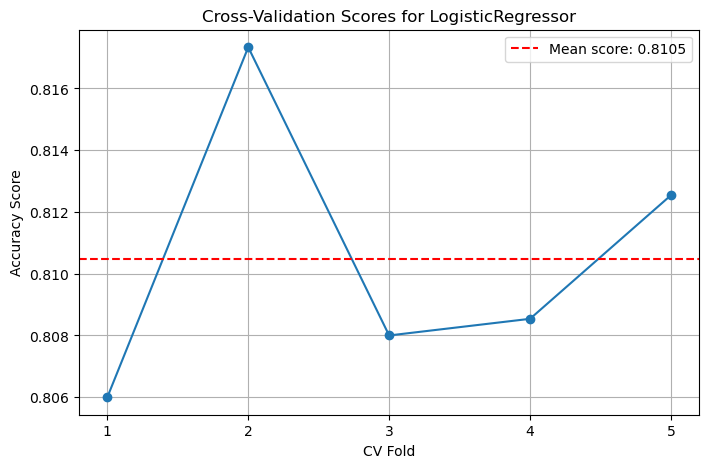

In [220]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# RandomForest

X_rf = X.copy()

encoder = OrdinalEncoder()

categorical_cols = X_rf.select_dtypes('object').columns
X_rf[categorical_cols] = encoder.fit_transform(X_rf[categorical_cols])

X_train_rt, X_test_rt, y_train_rt, y_test_rt = train_test_split(X_rf, y, random_state=0)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_scores = cross_val_score(rf, X_train_rt, y_train_rt, cv=5, scoring='accuracy')
print(f"RandomForest: {rf_scores.mean():.4f} (+/- {rf_scores.std() * 2:.4f})")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(rf_scores)+1), rf_scores, marker='o', linestyle='-')
plt.axhline(y=rf_scores.mean(), color='r', linestyle='--', label=f'Mean score: {rf_scores.mean():.4f}')
plt.title('Cross-Validation Scores for RandomForestClassifier')
plt.xlabel('CV Fold')
plt.ylabel('Accuracy Score')
plt.xticks(range(1, len(rf_scores)+1))
plt.legend()
plt.grid(True)
plt.show()

# Logistic Regressor

X_lr = X.copy()

scaler = StandardScaler()
continuous_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_lr[continuous_cols] = scaler.fit_transform(X_lr[continuous_cols])

categorical_cols = ['Geography', 'Gender']
X_lr = pd.get_dummies(X_lr, columns=categorical_cols, drop_first=True)
bool_cols = X_lr.select_dtypes('bool').columns
X_lr[bool_cols] = X_lr[bool_cols].astype(float)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y, random_state=0)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr_scores = cross_val_score(lr, X_train_lr, y_train_lr, cv=5, scoring='accuracy')
print(f"LogisticRegression: {lr_scores.mean():.4f} (+/- {lr_scores.std() * 2:.4f})")

plt.figure(figsize=(8,5)) 
plt.plot(range(1, len(lr_scores)+1), lr_scores, marker='o', linestyle='-')
plt.axhline(y=lr_scores.mean(), color='r', linestyle='--', label=f'Mean score: {lr_scores.mean():.4f}')
plt.title('Cross-Validation Scores for LogisticRegressor')
plt.xlabel('CV Fold')
plt.ylabel('Accuracy Score')
plt.xticks(range(1, len(lr_scores)+1))
plt.legend()
plt.grid(True)
plt.show()